In [1]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img
import matplotlib.pyplot as plt
import shutil

import random

In [18]:
PROCESSED_DIR = "../data/processed"
AUGMENTED_DIR = "../data/augmented"

# Định nghĩa minority classes cần augment
# MINORITY_CLASSES = {
#     "leaf_smut": 40,              # 28 → 2000 ảnh (tăng 71x)
#     "barrow_brown_leaf_spot": 749,# 1070 → 3000 ảnh (tăng 4x)
#     "neck_blast": 700,            # 1000 → 2500 ảnh (tăng 3.5x)
#     "tungro": 915,                # 1307 → 2500 ảnh (tăng 2.7x)
#     "rice_hispa": 1059,           # 1513 → 2500 ảnh (tăng 2.4x)
# }

MINORITY_CLASSES = {
    "leaf_smut": 40,
    "barrow_brown_leaf_spot": 1071,
    "neck_blast": 1000,
    "tungro": 1308,
    "rice_hispa": 1514,

    "bacterial_blight": 3345,
    "brown_spot": 4695,
    "healthy": 3383,
    "leaf_blast": 4582,
    "leaf_scald": 2149,
    "sheath_blight": 2532,
}

# MINORITY_CLASSES = [
#     "leaf_smut",
#     "barrow_brown_leaf_spot",
#     "neck_blast",
#     "tungro",
#     "rice_hispa",
# ]

# Target số ảnh sau augment
TARGET_SAMPLES = {
    "leaf_smut": 300,
    "barrow_brown_leaf_spot": 2000,
    "neck_blast": 2000,
    "tungro": 2000,
    "rice_hispa": 2000,

    "bacterial_blight": 4000,
    "brown_spot": 5100,
    "healthy": 4000,
    "leaf_blast": 5000,
    "leaf_scald": 3000,
    "sheath_blight": 3200,
}

In [19]:
augmentor = ImageDataGenerator(
    # rotation_range=40,
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    # shear_range=0.2,
    # zoom_range=0.3,
    # horizontal_flip=True,
    # vertical_flip=True,
    # brightness_range=[0.7, 1.3],
    # fill_mode='nearest'
    
    # Geometric
    rotation_range=45,           # Tăng lên 45°
    width_shift_range=0.25,      # Tăng lên 25%
    height_shift_range=0.25,
    shear_range=0.25,            # Thêm shear
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=True,
    
    # Color
    brightness_range=[0.6, 1.4],  # Tăng range
    fill_mode='nearest'
)

print(" Augmentor created")


 Augmentor created


In [20]:
def augment_class(class_name, target_count):
    """
    Augment một class đến target_count ảnh
    """
    src_dir = os.path.join(PROCESSED_DIR, class_name)
    dst_dir = os.path.join(AUGMENTED_DIR, class_name)
    os.makedirs(dst_dir, exist_ok=True)
    
    # Lấy ảnh gốc
    original_images = [f for f in os.listdir(src_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    current_count = len(original_images)
    
    print(f"\n{'='*70}")
    print(f"Class: {class_name}")
    print(f"{'='*70}")
    print(f"Original: {current_count} ảnh")
    print(f"Target:   {target_count} ảnh")
    print(f"Need to generate: {target_count - current_count} ảnh")
    
    # Copy ảnh gốc
    print("Copying original images...")
    for img_name in original_images:
        src = os.path.join(src_dir, img_name)
        dst = os.path.join(dst_dir, img_name)
        shutil.copy(src, dst)
    
    # Generate augmented images
    needed = target_count - current_count
    generated = 0
    
    print(f"Generating {needed} augmented images...")
    
    while generated < needed:
        # Chọn ảnh gốc ngẫu nhiên
        img_name = np.random.choice(original_images)
        img_path = os.path.join(src_dir, img_name)
        
        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        
        # Generate augmented image
        aug_iter = augmentor.flow(img_array, batch_size=1)
        aug_img = next(aug_iter)[0].astype('uint8')
        
        # Save
        base_name = os.path.splitext(img_name)[0]
        aug_name = f"{base_name}_aug_{generated:04d}.jpg"
        save_path = os.path.join(dst_dir, aug_name)
        
        aug_img_bgr = cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)
        cv2.imwrite(save_path, aug_img_bgr)
        
        generated += 1
        
        if generated % 100 == 0:
            print(f"  Progress: {generated}/{needed} ({generated/needed*100:.1f}%)")
    
    final_count = len(os.listdir(dst_dir))
    print(f" Done! Final count: {final_count} ảnh")
    
    return final_count

In [21]:
results = {}

for class_name, current_count in MINORITY_CLASSES.items():
# for class_name in MINORITY_CLASSES:
    target = TARGET_SAMPLES[class_name]
    final_count = augment_class(class_name, target)
    results[class_name] = {
        'original': current_count,
        'target': target,
        'final': final_count
    }


Class: leaf_smut
Original: 24 ảnh
Target:   300 ảnh
Need to generate: 276 ảnh
Copying original images...
Generating 276 augmented images...
  Progress: 100/276 (36.2%)
  Progress: 200/276 (72.5%)
 Done! Final count: 300 ảnh

Class: barrow_brown_leaf_spot
Original: 1071 ảnh
Target:   2000 ảnh
Need to generate: 929 ảnh
Copying original images...
Generating 929 augmented images...
  Progress: 100/929 (10.8%)
  Progress: 200/929 (21.5%)
  Progress: 300/929 (32.3%)
  Progress: 400/929 (43.1%)
  Progress: 500/929 (53.8%)
  Progress: 600/929 (64.6%)
  Progress: 700/929 (75.3%)
  Progress: 800/929 (86.1%)
  Progress: 900/929 (96.9%)
 Done! Final count: 2000 ảnh

Class: neck_blast
Original: 1000 ảnh
Target:   2000 ảnh
Need to generate: 1000 ảnh
Copying original images...
Generating 1000 augmented images...
  Progress: 100/1000 (10.0%)
  Progress: 200/1000 (20.0%)
  Progress: 300/1000 (30.0%)
  Progress: 400/1000 (40.0%)
  Progress: 500/1000 (50.0%)
  Progress: 600/1000 (60.0%)
  Progress: 700/

In [22]:
print(f"\n{'='*70}")
print("Copying majority classes (no augmentation)...")
print(f"{'='*70}")

ALL_CLASSES = [
    # "bacterial_blight",
    # "brown_spot",
    # "healthy",
    # "leaf_blast",
    # "leaf_scald",
    # "sheath_blight",
]

for class_name in ALL_CLASSES:
    src_dir = os.path.join(PROCESSED_DIR, class_name)
    dst_dir = os.path.join(AUGMENTED_DIR, class_name)
    
    if os.path.exists(dst_dir):
        continue
    
    print(f"  Copying {class_name}...")
    shutil.copytree(src_dir, dst_dir)
    
    count = len(os.listdir(dst_dir))
    results[class_name] = {
        'original': count,
        'target': count,
        'final': count
    }

print(" All classes copied")


Copying majority classes (no augmentation)...
 All classes copied


In [23]:
print("\n" + "="*70)
print("AUGMENTATION SUMMARY")
print("="*70)

total_before = 0
total_after = 0

for class_name in sorted(results.keys()):
    info = results[class_name]
    orig = info['original']
    final = info['final']
    increase = ((final - orig) / orig * 100) if orig > 0 else 0
    
    total_before += orig
    total_after += final
    
    print(f"{class_name:25s}: {orig:5d} → {final:5d} (+{increase:6.1f}%)")

print(f"{'='*70}")
print(f"{'TOTAL':25s}: {total_before:5d} → {total_after:5d} (+{(total_after-total_before)/total_before*100:.1f}%)")
print(f"{'='*70}")


AUGMENTATION SUMMARY
bacterial_blight         :  3345 →  4000 (+  19.6%)
barrow_brown_leaf_spot   :  1071 →  2000 (+  86.7%)
brown_spot               :  4695 →  5100 (+   8.6%)
healthy                  :  3383 →  4000 (+  18.2%)
leaf_blast               :  4582 →  5000 (+   9.1%)
leaf_scald               :  2149 →  3000 (+  39.6%)
leaf_smut                :    40 →   300 (+ 650.0%)
neck_blast               :  1000 →  2000 (+ 100.0%)
rice_hispa               :  1514 →  2000 (+  32.1%)
sheath_blight            :  2532 →  3200 (+  26.4%)
tungro                   :  1308 →  2000 (+  52.9%)
TOTAL                    : 25619 → 32600 (+27.2%)


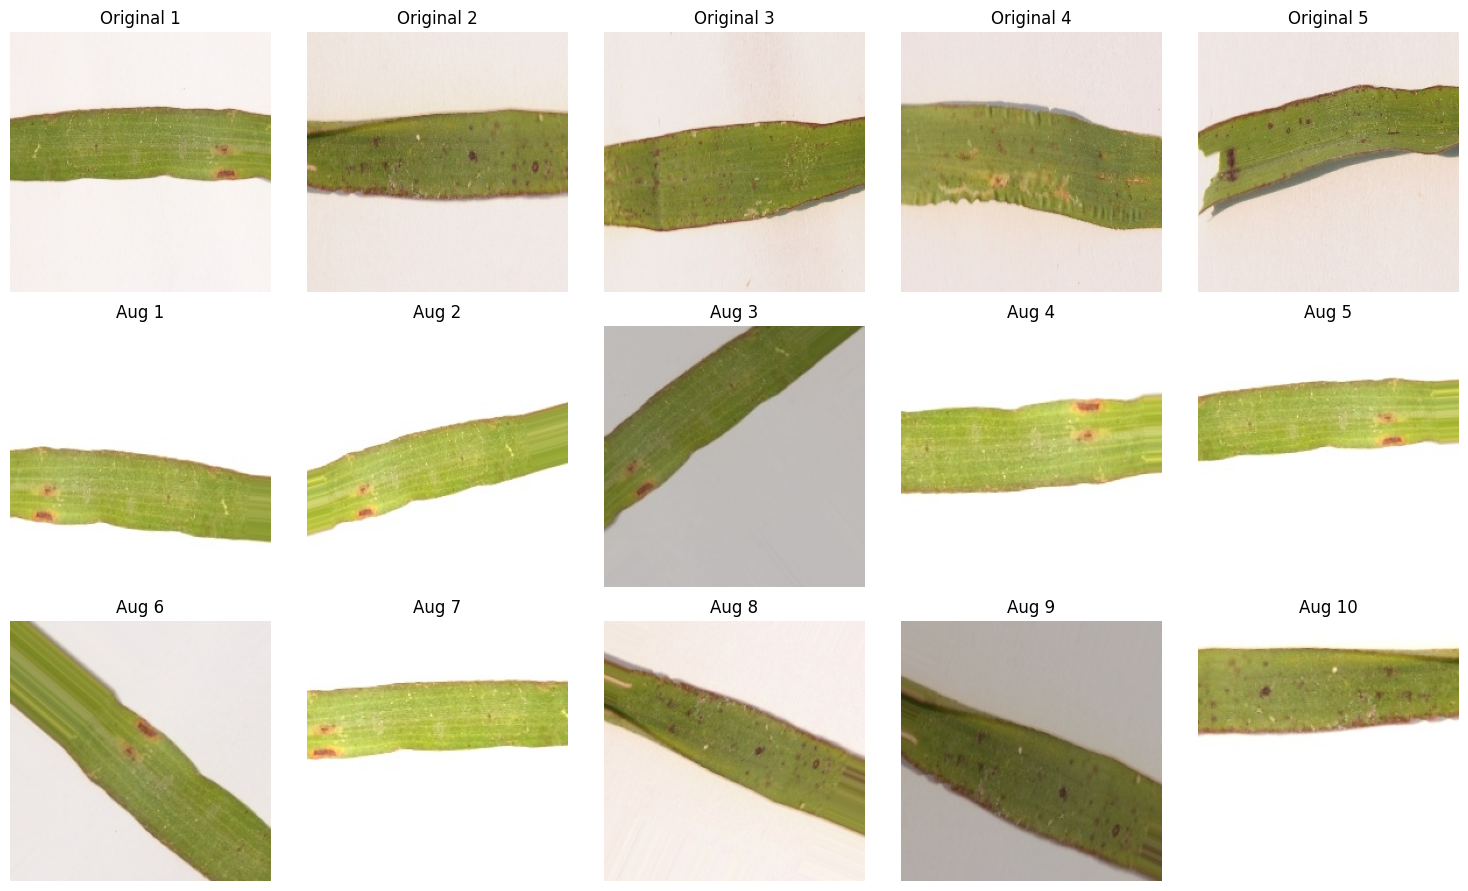

 Visualization saved to ../models/augmentation_examples.png


In [24]:
# Chọn một minority class
class_to_viz = "leaf_smut"
aug_dir = os.path.join(AUGMENTED_DIR, class_to_viz)

# Lấy ảnh gốc và augmented
original_imgs = [f for f in os.listdir(aug_dir) if not 'aug' in f][:5]
augmented_imgs = [f for f in os.listdir(aug_dir) if 'aug' in f][:10]

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Row 1: Original
for i, img_name in enumerate(original_imgs):
    img = cv2.imread(os.path.join(aug_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Original {i+1}")
    axes[0, i].axis('off')

# Row 2-3: Augmented
for i, img_name in enumerate(augmented_imgs):
    row = 1 + i // 5
    col = i % 5
    img = cv2.imread(os.path.join(aug_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[row, col].imshow(img)
    axes[row, col].set_title(f"Aug {i+1}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig("../models/augmentation_examples.png", dpi=150)
plt.show()

print(f" Visualization saved to ../models/augmentation_examples.png")

In [25]:
print("\n" + "="*70)
print(" AUGMENTATION COMPLETE!")
print("="*70)
print(f"Augmented dataset location: {AUGMENTED_DIR}")
print(f"Total images: {total_after:,}")
print("\n NEXT STEP:")
print("   Run 02_prepare_data.ipynb với AUGMENTED_DIR thay vì PROCESSED_DIR")
print("="*70)


 AUGMENTATION COMPLETE!
Augmented dataset location: ../data/augmented
Total images: 32,600

 NEXT STEP:
   Run 02_prepare_data.ipynb với AUGMENTED_DIR thay vì PROCESSED_DIR
